In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import dwave_nl_sharpe

# Load D-Wave API token from .env file
from dotenv import load_dotenv
load_dotenv()

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Quantum Portfolio Optimization using D-Wave CQM Solver

In [2]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

### Path definition

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


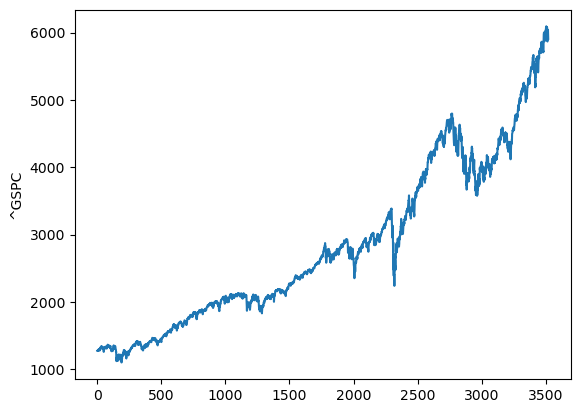

In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [5]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Correlation Analysis

* Determine a set of stocks with minimal correlation

In [6]:
df_corr = source.corr()
df_corr.head()

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Ticker,,,,,,,,,,,,,,,,,,,,,
A,1.000000,0.938434,0.972057,0.803930,0.973666,0.944446,0.958391,0.877209,0.950709,0.946486,...,0.915526,0.962450,0.952409,0.840455,-0.192150,0.925082,0.581125,0.957106,0.742547,0.926361
AAPL,0.938434,1.000000,0.925958,0.904199,0.965640,0.912658,0.974905,0.858673,0.957237,0.883810,...,0.954041,0.944027,0.944347,0.799052,-0.274004,0.864298,0.709763,0.932155,0.609996,0.834967
ABT,0.972057,0.925958,1.000000,0.780764,0.974008,0.966874,0.947089,0.840192,0.947416,0.967112,...,0.905557,0.957242,0.959083,0.826124,-0.199613,0.959269,0.502779,0.961910,0.787986,0.938066
ACGL,0.803930,0.904199,0.780764,1.000000,0.859009,0.772929,0.921957,0.746998,0.908116,0.731481,...,0.943648,0.783657,0.889515,0.726342,-0.175307,0.746701,0.854873,0.878777,0.539229,0.617688
ACN,0.973666,0.965640,0.974008,0.859009,1.000000,0.962718,0.975225,0.861665,0.975261,0.940212,...,0.947315,0.970085,0.967641,0.856489,-0.227554,0.926912,0.623003,0.971591,0.727454,0.899654


#### Rank correlation ascending

In [7]:
# rank by correlation
corr_sum = df_corr.map(lambda x: abs(x)).sum()
corr_rank = corr_sum.sort_values().rank(method='min').astype(int)
corr_rank

Ticker
TPR       1
BKR       2
GE        3
WYNN      4
DVN       5
       ... 
TXN     435
TEL     436
ITW     437
ICE     438
HD      439
Length: 439, dtype: int64

#### Rank returns descending

In [8]:
# rank by returns
return_rank = source.diff().sum(axis=0).sort_values().rank(method='min', ascending=False).astype(int)
return_rank

Ticker
APA     439
MOS     438
SLB     437
DVN     436
PCG     435
       ... 
TDG       5
FICO      4
AZO       3
BKNG      2
NVR       1
Length: 439, dtype: int64

### Portfolio Stats

In [9]:
def portfolio_stats(weights, data):
    logger.info("=== portfolio_stats START ===")
    logger.info(f"Input weights shape: {np.array(weights).shape}")
    logger.info(f"Input data shape: {data.shape}")
    
    weights = np.array(weights)
    logger.info("Calculating log returns...")
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    logger.info(f"Log returns calculated, shape: {returns.shape}")
    
    # CONSISTENT: Always use log returns, never pct_change()
    logger.info("Calculating portfolio return...")
    port_return = np.sum(returns.mean() * weights) 
    logger.info(f"Portfolio return: {port_return}")
    
    logger.info("Calculating portfolio volatility...")
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    logger.info(f"Portfolio volatility: {port_vol}")
    
    try:
        sharpe_ratio = port_return/port_vol
        logger.info(f"Sharpe ratio: {sharpe_ratio}")
    except Exception as e:
        logger.warning(f"Sharpe ratio calculation failed: {e}")
        sharpe_ratio = 0
    
    logger.info("=== portfolio_stats END ===")
    return sharpe_ratio, port_return, port_vol

### Data generator

Data generator to instantiate blocks on demand

In [10]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [11]:
def backtest(optimization_function, data, benchmark, budget, avg_period, opt_period):
    logger.info("="*80)
    logger.info("=== BACKTEST START ===")
    logger.info(f"Data shape: {data.shape}, Benchmark shape: {benchmark.shape}")
    logger.info(f"Budget: {budget}, Avg period: {avg_period}, Opt period: {opt_period}")
    
    portfolio_value = budget
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value

    logger.info(f"Starting backtest loop for {opt_period} iterations...")
    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        logger.info(f"\n--- Iteration {i-avg_period}/{opt_period} (j={j}, i={i}) ---")
        
        df = data.iloc[j:i, :]
        logger.info(f"Data slice shape: {df.shape}, Date range: {df.index[0]} to {df.index[-1]}")
        
        # Use log returns for consistency with optimization functions
        logger.info("Calculating log returns for slice...")
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        logger.info(f"Log returns shape after dropna: {df_log_returns.shape}")
        
        #logger.debug(f'df_log_returns: {df_log_returns}')
        weights = optimization_function(df)
        logger.info(f"Optimization completed. Weights shape: {weights.shape}, Sum: {weights.sum():.6f}")
        logger.info(f"Weights min: {weights.min():.6f}, max: {weights.max():.6f}, non-zero count: {(weights > 0).sum()}")
        
        weights[weights < 0] = 0
        weights /= weights.sum()
        logger.info(f"Weights after normalization - Sum: {weights.sum():.6f}")
        
        weights_history.loc[df.index[-1]] = weights
        #sharpe_ratio, portfolio_return, portfolio_volatility = portfolio_stats(weights, df)
        # portfolio_change = df.iloc[-2:, :].pct_change() * weights
        logger.info("Calculating portfolio change...")
        portfolio_change = df_log_returns.iloc[-1] * weights
        #portfolio_return = portfolio_change.sum(axis=1).iloc[-1]
        portfolio_return = portfolio_change.sum()
        logger.info(f"Portfolio return for this period: {portfolio_return:.6f}")
        
        portfolio_returns.append(portfolio_return)
        # print(f'portfolio returns: {portfolio_returns}')
        # Use log returns for benchmark as well
        logger.info("Calculating benchmark returns...")
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        logger.info(f"Benchmark return for this period: {benchmark_return:.6f}")
        
        benchmark_returns.append(benchmark_return)
        # print(f'benchmark_returns: {benchmark_returns}')
        logger.info("Calculating cumulative returns...")
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns]) - 1  # Convert to percentage returns
        # print(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in benchmark_returns]) - 1  # Convert to percentage returns
        # print(f'benchmark cumulative returns: {benchmark_cumulative_returns}')
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        logger.info(f"Portfolio mean return: {portfolio_mean_return:.6f}, volatility: {portfolio_volatility:.6f}")
        logger.info(f"Benchmark mean return: {benchmark_mean_return:.6f}, volatility: {benchmark_volatility:.6f}")
        
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
            logger.info(f"Sharpe ratio: {sharpe_ratio:.6f}")
        except Exception as e:
            logger.warning(f"Sharpe ratio calculation failed: {e}")
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

         # Portfolio & Benchmark value
        benchmark_value = budget * benchmark_cumulative_returns[-1]
        portfolio_value = budget * portfolio_cumulative_returns[-1]
        logger.info(f"Portfolio value: ${portfolio_value:,.2f}, Benchmark value: ${benchmark_value:,.2f}")
        j += 1

    logger.info("=== BACKTEST END ===")
    logger.info("="*80)
    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [12]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict


### Run Experiment Function

In [13]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters):
    logger.info("\n" + "#"*100)
    logger.info("### RUN EXPERIMENT START ###")
    logger.info("#"*100)
    logger.info(f"Results path template: {results_path_template}")
    logger.info(f"Data shape: {data.shape}")
    logger.info(f"Benchmark shape: {benchmark.shape}")
    logger.info(f"Parameters: {parameters}")

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    budget = parameters['budget']
    
    logger.info(f"Creating data generator with n_periods={n_periods}...")
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        logger.info(f"\n{'='*80}")
        logger.info(f"PERIOD {i+1}/{n_periods}")
        logger.info(f"{'='*80}")
        
        results_path = results_path_template.format(i)
        logger.info(f"Results path: {results_path}")
        
        if not os.path.exists(results_path):
            logger.info(f"Results file does not exist, running optimization...")
            try:
                logger.info("Getting next data sample from generator...")
                df, df_b = next(datagen)
                logger.info(f"Data sample retrieved - df shape: {df.shape}, benchmark shape: {df_b.shape}")
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                
                logger.info("Creating source data plot...")
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                
                logger.info(f"Starting backtest at {datetime.now()}")
                start_time = datetime.now()
                
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(opt_fun, df, df_b, budget=budget, avg_period=days_to_avg,opt_period=days_to_opt)
                
                end_time = datetime.now()
                dt = abs(end_time - start_time)
                logger.info(f'Backtest completed at {end_time}')
                logger.info(f'Total backtest time: {dt.total_seconds():.2f} seconds')
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                
            except Exception as e: 
                logger.error(f'FAILED {results_path} due to {e}', exc_info=True)
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []
                dt = timedelta(0)

            logger.info("Saving results to pickle file...")
            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)
            logger.info(f"Results saved successfully to {results_path}")

        else:
            logger.info(f"Results file already exists, loading from {results_path}...")
            results = read_pickle_dict(results_path)
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']
            logger.info(f"Results loaded - portfolio return: {portfolio_cumulative_returns[-1] if len(portfolio_cumulative_returns) > 0 else 'N/A'}")

            # Plot the results
            logger.info("Creating results plot...")
            plt.figure(figsize=(12, 6))
            plt.plot(portfolio_cumulative_returns, label='Portfolio')
            plt.plot(benchmark_cumulative_returns, label='Benchmark')
            plt.legend(loc='upper left')
            plt.title('Backtesting Results')
            plt.xlabel('Date')
            plt.ylabel('Cumulative Returns')
            plt.show()

    logger.info("\n" + "#"*100)
    logger.info("### RUN EXPERIMENT END ###")
    logger.info("#"*100 + "\n")
    return None

### Performance Analysis Functions

In [14]:
def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()

### Global Parameters

CQM-specific parameters for quantum optimization

In [15]:
parameters = {
    "n_periods": 1,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "budget": 1_000_000.0,
    "min_investment": 0.0001,
}

### Experiment: Wide Dataset (Stocks + ETFs)

In [21]:
source_path_extended = '../../data/etfs_close.pkl'

In [22]:
source_extended = pd.read_pickle(source_path_extended)
source_extended.head()

Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [23]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(source_wide.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_wide.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source_wide.head()

(3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


initial date: 2014-01-13 00:00:00


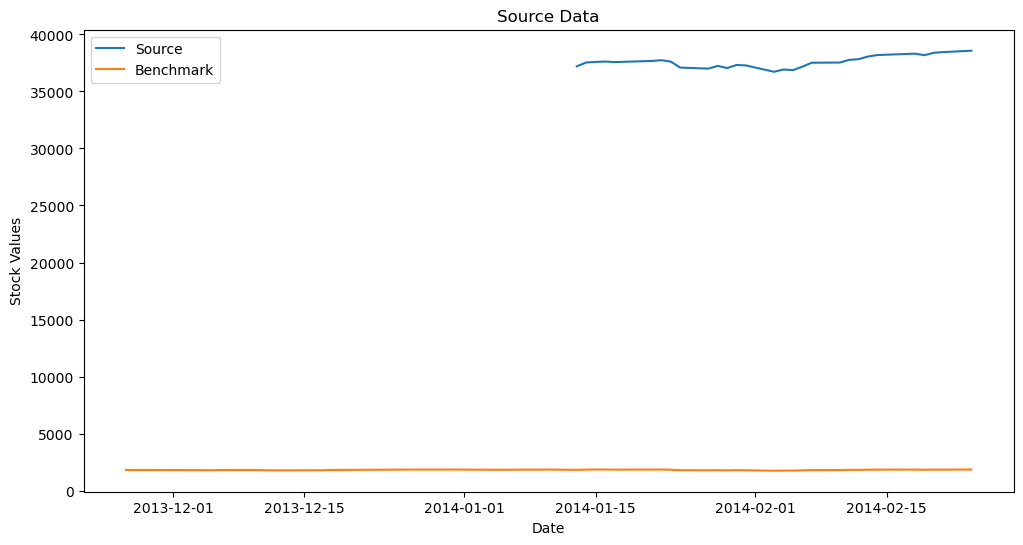

D-Wave NL Sharpe Optimization Started
Input Parameters:
  - Budget: 1000000.0
  - Min Investment: 0.0001
  - Data shape: (31, 680)
  - Assets: ['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB', 'ALGN', 'ALL', 'AMAT', 'AMD', 'AME', 'AMGN', 'AMP', 'AMT', 'AMZN', 'ANSS', 'AON', 'AOS', 'APA', 'APD', 'APH', 'ARE', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBY', 'BDX', 'BEN', 'BG', 'BIIB', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK', 'BMY', 'BR', 'BRO', 'BSX', 'BWA', 'BX', 'BXP', 'C', 'CAG', 'CAH', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CE', 'CF', 'CHD', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX', 'CMCSA', 'CME', 'CMG', 'CMI', 'CMS', 'CNC', 'CNP', 'COF', 'COO', 'COP', 'COR', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRL', 'CRM', 'CSCO', 'CSGP', 'CSX', 'CTAS', 'CTRA', 'CTSH', 'CVS', 'CVX', 'D', 'DAL', 'DD', 'DE', 'DECK', 'DFS', 'DG', 'DGX', 'DHI', 'DHR', 'DIS', 'D

In [ ]:
results_path_cqm_wide = '../../results/sharpe_optimization_diversified/results_wide_{}_cqm.pkl'
_ = run_experiment(results_path_cqm_wide, source_wide, benchmark, opt_fun_cqm, parameters)

#### Performance Analysis for Wide Dataset

In [23]:
# Performance analysis for CQM optimization (Wide Dataset - Stocks + ETFs)
cqm_wide_solvers = [
    {'path_template': '../../results/sharpe_optimization_diversified/results_wide_{}_cqm.pkl', 'name': 'D-Wave CQM Sharpe'},
]

print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM Optimization (Wide Dataset - Stocks + ETFs)")
print("="*100)
summary_df = performance_summary(cqm_wide_solvers, n_periods)
if not summary_df.empty:
    display(summary_df)
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Successful periods: {summary_df.iloc[0]['Periods']}/{n_periods}")
    print(f"Average return: {summary_df.iloc[0]['Avg_Return']:.4f}")
    print(f"Average execution time: {summary_df.iloc[0]['Avg_Time']:.2f}s")
    print(f"Success rate: {summary_df.iloc[0]['Success_Rate']:.1f}%")
else:
    print("No summary data available")


COMPREHENSIVE PERFORMANCE SUMMARY - D-Wave CQM Optimization (Wide Dataset - Stocks + ETFs)


,Solver,Periods,Avg_Return,Std_Return,Min_Return,Max_Return,Avg_Time,Std_Time,Success_Rate
0,D-Wave CQM Sharpe,8,0.0633,0.0235,0.0345,0.1011,364.6904,58.7914,80.0



Performance Analysis:
--------------------------------------------------
Successful periods: 8/10
Average return: 0.0633
Average execution time: 364.69s
Success rate: 80.0%


In [ ]:
# Plot results of wide dataset run vs benchmark
results_path_wide = results_path_dwave_nl_wide.format(0)
if os.path.exists(results_path_wide):
    print("Loading results from:", results_path_wide)
    results = read_pickle_dict(results_path_wide)
    
    portfolio_cumulative_returns = results['portfolio_cumulative_returns']
    benchmark_cumulative_returns = results['benchmark_cumulative_returns']
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('D-Wave NL Sharpe Optimization - Wide Dataset Results (680 assets)', fontsize=16, fontweight='bold')
    
    # Plot 1: Cumulative Returns Comparison
    ax1 = axes[0, 0]
    ax1.plot(portfolio_cumulative_returns, label='D-Wave NL Portfolio', linewidth=2, color='#2E86AB')
    ax1.plot(benchmark_cumulative_returns, label='S&P 500 Benchmark', linewidth=2, color='#A23B72', linestyle='--')
    ax1.set_xlabel('Trading Days')
    ax1.set_ylabel('Cumulative Returns')
    ax1.set_title('Cumulative Returns: Portfolio vs Benchmark')
    ax1.legend(loc='best')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Relative Performance
    ax2 = axes[0, 1]
    relative_performance = np.array(portfolio_cumulative_returns) - np.array(benchmark_cumulative_returns)
    ax2.plot(relative_performance, linewidth=2, color='#F18F01')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.fill_between(range(len(relative_performance)), relative_performance, 0, 
                      where=(relative_performance >= 0), alpha=0.3, color='green', label='Outperformance')
    ax2.fill_between(range(len(relative_performance)), relative_performance, 0, 
                      where=(relative_performance < 0), alpha=0.3, color='red', label='Underperformance')
    ax2.set_xlabel('Trading Days')
    ax2.set_ylabel('Return Difference')
    ax2.set_title('Portfolio Excess Returns vs Benchmark')
    ax2.legend(loc='best')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Summary Statistics
    ax3 = axes[1, 0]
    ax3.axis('off')
    
    portfolio_final = portfolio_cumulative_returns[-1] if len(portfolio_cumulative_returns) > 0 else 0
    benchmark_final = benchmark_cumulative_returns[-1] if len(benchmark_cumulative_returns) > 0 else 0
    outperformance = portfolio_final - benchmark_final
    outperformance_pct = (outperformance / benchmark_final * 100) if benchmark_final != 0 else 0
    
    portfolio_vol = np.std(portfolio_cumulative_returns) if len(portfolio_cumulative_returns) > 1 else 0
    benchmark_vol = np.std(benchmark_cumulative_returns) if len(benchmark_cumulative_returns) > 1 else 0
    
    stats_text = f"""
    Performance Summary (680 Assets)
    {'='*50}
    
    Portfolio Final Return:      {portfolio_final:.4f} ({portfolio_final*100:.2f}%)
    Benchmark Final Return:      {benchmark_final:.4f} ({benchmark_final*100:.2f}%)
    
    Excess Return:               {outperformance:.4f} ({outperformance_pct:+.2f}%)
    
    Portfolio Volatility (Std):  {portfolio_vol:.4f}
    Benchmark Volatility (Std):  {benchmark_vol:.4f}
    
    Number of Periods:           {len(portfolio_cumulative_returns)}
    Execution Time:              {results.get('total_run_time', 0):.2f}s
    
    Date Range:                  {results.get('start_date', 'N/A')} 
                                 to {results.get('end_date', 'N/A')}
    """
    
    ax3.text(0.1, 0.5, stats_text, transform=ax3.transAxes, fontsize=11,
             verticalalignment='center', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    # Plot 4: Rolling Performance
    ax4 = axes[1, 1]
    window = min(5, len(portfolio_cumulative_returns))
    if len(portfolio_cumulative_returns) > window:
        portfolio_rolling = pd.Series(portfolio_cumulative_returns).rolling(window=window).mean()
        benchmark_rolling = pd.Series(benchmark_cumulative_returns).rolling(window=window).mean()
        
        ax4.plot(portfolio_rolling, label=f'Portfolio ({window}-day MA)', linewidth=2, color='#2E86AB')
        ax4.plot(benchmark_rolling, label=f'Benchmark ({window}-day MA)', linewidth=2, color='#A23B72', linestyle='--')
        ax4.set_xlabel('Trading Days')
        ax4.set_ylabel('Returns (Moving Average)')
        ax4.set_title(f'{window}-Day Moving Average Returns')
        ax4.legend(loc='best')
        ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data\nfor moving average', 
                ha='center', va='center', transform=ax4.transAxes, fontsize=12)
        ax4.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("RESULTS VISUALIZATION COMPLETE")
    print("="*80)
else:
    print(f"Results file not found: {results_path_wide}")
    print("Run the optimization first by executing the cell above.")

## D-Wave vs Classical Solvers - Trace Comparison

Compare the portfolio performance trace of D-Wave CQM against classical solvers for the same period.

In [ ]:
# Create comprehensive comparison visualization
if len(results_dict) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('D-Wave CQM vs Classical Sharpe Optimization - Wide Dataset (680 Assets)', 
                 fontsize=16, fontweight='bold')
    
    # Define color scheme
    colors = {
        'D-Wave CQM': '#F18F01',
        'Equal Weights': '#2D3142',
        'Genetic Algorithm': '#06A77D',
        'Scipy SLSQP': '#2E86AB',
        'Hierarchical Risk Parity': '#A23B72'
    }
    
    # Plot 1: Cumulative Returns Comparison
    ax1 = axes[0, 0]
    for solver_name, results in results_dict.items():
        portfolio_returns = results.get('portfolio_cumulative_returns', [])
        if len(portfolio_returns) > 0:
            color = colors.get(solver_name, '#333333')
            linewidth = 2.5 if solver_name == 'D-Wave CQM' else 1.5
            linestyle = '-' if solver_name == 'D-Wave CQM' else '--'
            ax1.plot(portfolio_returns, label=solver_name, 
                    color=color, linewidth=linewidth, linestyle=linestyle)
    
    # Add benchmark
    if dwave_results:
        benchmark_returns = dwave_results.get('benchmark_cumulative_returns', [])
        if len(benchmark_returns) > 0:
            ax1.plot(benchmark_returns, label='S&P 500', 
                    color='black', linewidth=1, linestyle=':', alpha=0.6)
    
    ax1.set_xlabel('Trading Days')
    ax1.set_ylabel('Cumulative Returns')
    ax1.set_title('Cumulative Returns Over Time')
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Final Returns Bar Chart
    ax2 = axes[0, 1]
    final_returns = []
    solver_names = []
    bar_colors = []
    
    for solver_name, results in results_dict.items():
        portfolio_returns = results.get('portfolio_cumulative_returns', [])
        if len(portfolio_returns) > 0:
            final_returns.append(portfolio_returns[-1])
            solver_names.append(solver_name)
            bar_colors.append(colors.get(solver_name, '#333333'))
    
    bars = ax2.bar(range(len(final_returns)), final_returns, color=bar_colors, alpha=0.8)
    ax2.set_xticks(range(len(solver_names)))
    ax2.set_xticklabels(solver_names, rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Final Return')
    ax2.set_title('Final Returns Comparison')
    ax2.grid(True, axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, final_returns)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.4f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 3: Execution Time Comparison
    ax3 = axes[1, 0]
    exec_times = []
    time_solver_names = []
    time_colors = []
    
    for solver_name, results in results_dict.items():
        exec_time = results.get('total_run_time', 0)
        exec_times.append(exec_time)
        time_solver_names.append(solver_name)
        time_colors.append(colors.get(solver_name, '#333333'))
    
    bars = ax3.bar(range(len(exec_times)), exec_times, color=time_colors, alpha=0.8)
    ax3.set_xticks(range(len(time_solver_names)))
    ax3.set_xticklabels(time_solver_names, rotation=45, ha='right', fontsize=9)
    ax3.set_ylabel('Time (seconds)')
    ax3.set_title('Execution Time Comparison')
    ax3.set_yscale('log')  # Log scale for better visibility
    ax3.grid(True, axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, exec_times)):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{value:.1f}s', ha='center', va='bottom', fontsize=8)
    
    # Plot 4: Summary Statistics Table
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # Create summary table
    summary_data = []
    for solver_name, results in results_dict.items():
        portfolio_returns = results.get('portfolio_cumulative_returns', [])
        exec_time = results.get('total_run_time', 0)
        
        if len(portfolio_returns) > 0:
            final_return = portfolio_returns[-1]
            volatility = np.std(portfolio_returns)
            sharpe = (np.mean(portfolio_returns) / volatility) if volatility > 0 else 0
            
            summary_data.append([
                solver_name,
                f'{final_return:.4f}',
                f'{volatility:.4f}',
                f'{sharpe:.4f}',
                f'{exec_time:.1f}s'
            ])
    
    # Sort by final return (descending)
    summary_data.sort(key=lambda x: float(x[1]), reverse=True)
    
    table = ax4.table(cellText=summary_data,
                     colLabels=['Solver', 'Final Return', 'Volatility', 'Sharpe Ratio', 'Time'],
                     cellLoc='left',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    # Color code the rows
    for i, row_data in enumerate(summary_data):
        solver = row_data[0]
        color = colors.get(solver, '#FFFFFF')
        table[(i+1, 0)].set_facecolor(color)
        table[(i+1, 0)].set_alpha(0.3)
    
    # Highlight D-Wave row
    for i, row_data in enumerate(summary_data):
        if row_data[0] == 'D-Wave CQM':
            for j in range(5):
                table[(i+1, j)].set_linewidth(2)
                table[(i+1, j)].set_edgecolor('#F18F01')
    
    ax4.set_title('Performance Summary', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison
    print("\n" + "="*100)
    print("DETAILED PERFORMANCE COMPARISON - D-Wave CQM vs Classical Sharpe Optimization")
    print("="*100)
    
    if 'D-Wave CQM' in results_dict:
        dwave_return = results_dict['D-Wave CQM']['portfolio_cumulative_returns'][-1]
        dwave_time = results_dict['D-Wave CQM']['total_run_time']
        
        print(f"\nD-Wave CQM Quantum Solver:")
        print(f"  Final Return: {dwave_return:.4f} ({dwave_return*100:.2f}%)")
        print(f"  Execution Time: {dwave_time:.2f}s")
        
        print(f"\nComparison with Classical Solvers:")
        for solver_name, results in results_dict.items():
            if solver_name != 'D-Wave CQM':
                classical_return = results['portfolio_cumulative_returns'][-1]
                classical_time = results['total_run_time']
                return_diff = dwave_return - classical_return
                return_diff_pct = (return_diff / abs(classical_return) * 100) if classical_return != 0 else 0
                time_ratio = dwave_time / classical_time if classical_time > 0 else 0
                
                print(f"\n  vs {solver_name}:")
                print(f"    Return Difference: {return_diff:+.4f} ({return_diff_pct:+.2f}%)")
                print(f"    Time Ratio: {time_ratio:.2f}x {'faster' if time_ratio < 1 else 'slower'}")
    
    print("\n" + "="*100)
    
else:
    print("No results available for comparison")

In [ ]:
# Load D-Wave quantum results
dwave_path = '../../results/sharpe_optimization_diversified/results_wide_0_cqm.pkl'

# Load classical solver results for the same period
classical_paths = {
    'Equal Weights': '../../results/sharpe_optimization_diversified/results_wide_0_ew.pkl',
    'Genetic Algorithm': '../../results/sharpe_optimization_diversified/results_wide_0_ga.pkl',
    'Scipy SLSQP': '../../results/sharpe_optimization_diversified/results_wide_0_bf.pkl',
    'Hierarchical Risk Parity': '../../results/sharpe_optimization_diversified/results_wide_0_hrp.pkl',
}

# Load all results
results_dict = {}

if os.path.exists(dwave_path):
    dwave_results = read_pickle_dict(dwave_path)
    results_dict['D-Wave CQM'] = dwave_results
    print(f"✓ Loaded D-Wave CQM results")
else:
    print(f"✗ D-Wave results not found: {dwave_path}")
    dwave_results = None

for solver_name, path in classical_paths.items():
    if os.path.exists(path):
        results_dict[solver_name] = read_pickle_dict(path)
        print(f"✓ Loaded {solver_name} results")
    else:
        print(f"✗ {solver_name} results not found: {path}")

print(f"\nTotal solvers loaded: {len(results_dict)}")